In [2]:
!pip  install shap
!pip install catboost
!pip install xgboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression,  LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import catboost
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
# %% [markdown]
# 🧩 STRESSense-X: Multimodal Transformer with Personalization and Explainability
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt





In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/stress classification/data.csv")


In [6]:
df.isnull().sum()

,0
ID,0
Timestamp,0
ACC_x,0
ACC_y,0
ACC_z,0
BVP,0
EDA,0
HR,0
IBI_d,0
TEMP,0


In [7]:
df.head()

,ID,Timestamp,ACC_x,ACC_y,ACC_z,BVP,EDA,HR,IBI_d,TEMP,Stress
0,1,1.644226e+09,-2.0,43.0,43.0,0.00,0.000000,83.0,0.921875,28.39,0
1,1,1.644226e+09,-7.0,39.0,50.0,93.76,0.167844,83.0,0.921875,28.39,0
2,1,1.644226e+09,-6.0,39.0,50.0,142.62,0.165282,83.0,0.921875,28.39,0
3,1,1.644226e+09,-6.0,38.0,51.0,-12.02,0.165282,83.0,0.921875,28.39,0
4,1,1.644226e+09,-11.0,15.0,61.0,38.78,0.166563,83.0,0.921875,28.37,0


In [8]:
df.dtypes

,0
ID,int64
Timestamp,float64
ACC_x,float64
ACC_y,float64
ACC_z,float64
BVP,float64
EDA,float64
HR,float64
IBI_d,float64
TEMP,float64


In [9]:
# Step 1: Convert all float columns to integers
df = df.round(0).astype(int)

In [10]:
df.dtypes

,0
ID,int64
Timestamp,int64
ACC_x,int64
ACC_y,int64
ACC_z,int64
BVP,int64
EDA,int64
HR,int64
IBI_d,int64
TEMP,int64


In [11]:
df.to_csv("encoded_data.csv")

In [26]:
# Define X (features) and y (target)
X = df.drop(columns=['Stress'])  # Features: all columns except 'fire'
y = df['Stress']

In [27]:
X.head()

,ID,Timestamp,ACC_x,ACC_y,ACC_z,BVP,EDA,HR,IBI_d,TEMP
0,1,1644226061,-2,43,43,0,0,83,1,28
1,1,1644226062,-7,39,50,94,0,83,1,28
2,1,1644226063,-6,39,50,143,0,83,1,28
3,1,1644226064,-6,38,51,-12,0,83,1,28
4,1,1644226065,-11,15,61,39,0,83,1,28


In [28]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split the data first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

**Exsisted models**

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Accuracy: 98.40%


In [44]:
from sklearn.neighbors import KNeighborsClassifier

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")


KNN Accuracy: 97.77%


In [45]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Reshape input to [samples, timesteps, features]
X_train_reshaped = np.expand_dims(X_train_resampled, axis=1)
X_test_reshaped = np.expand_dims(X_test, axis=1)

# LSTM Model
lstm = Sequential([
    LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # use softmax if multiclass
])

lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train
lstm.fit(X_train_reshaped, y_train_resampled, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate
lstm_loss, lstm_accuracy = lstm.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"LSTM Accuracy: {lstm_accuracy * 100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6235 - loss: 0.6644 - val_accuracy: 0.0000e+00 - val_loss: 0.9481
Epoch 2/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6254 - loss: 0.6623 - val_accuracy: 0.0000e+00 - val_loss: 0.9238
Epoch 3/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6264 - loss: 0.6615 - val_accuracy: 0.0000e+00 - val_loss: 0.8810
Epoch 4/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6273 - loss: 0.6608 - val_accuracy: 0.0000e+00 - val_loss: 0.9588
Epoch 5/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6270 - loss: 0.6608 - val_accuracy: 0.0000e+00 - val_loss: 0.9799
Epoch 6/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6223 - loss: 0.6632 - val_accuracy: 0.0000e+00 - val_loss: 0.9421
Epoch 7/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6279 - loss: 0.6605 - val_accuracy: 0.0000e+00 - val_loss: 0.9782
Epoch 8/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accur

In [ ]:
from sklearn.svm import SVC

# SVM Model
svm = SVC()
svm.fit(X_train_resampled, y_train_resampled)
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")


In [ ]:
# ---------------------------
# Neural Network (CNN) - Separate Model
# ---------------------------
cnn_model = Sequential()
cnn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_resampled, y_train_resampled, epochs=10, batch_size=32, verbose=1)

cnn_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"CNN Model Accuracy: {cnn_accuracy[1] * 100:.2f}%")


**proposed models**

In [16]:
# %%
# Assuming last column is the label, adjust if needed
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Normalize for stable training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)


In [17]:
# %%
class StressDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = StressDataset(X_train_t, y_train_t)
test_ds = StressDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32)


In [18]:
# %%
class STRESSenseX(nn.Module):
    def __init__(self, input_dim, num_classes=2, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Transformer expects (seq_len, batch, embed_dim)
        x = self.embedding(x).unsqueeze(0)
        x = self.transformer(x)
        x = x.mean(dim=0)
        return self.classifier(x)

# Initialize model
input_dim = X_train.shape[1]
model = STRESSenseX(input_dim=input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)


STRESSenseX(
  (embedding): Linear(in_features=10, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [19]:
# %%
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/10 | Loss: 0.5690
Epoch 2/10 | Loss: 0.4596
Epoch 3/10 | Loss: 0.3868
Epoch 4/10 | Loss: 0.3482
Epoch 5/10 | Loss: 0.3230
Epoch 6/10 | Loss: 0.3056
Epoch 7/10 | Loss: 0.2904
Epoch 8/10 | Loss: 0.2775
Epoch 9/10 | Loss: 0.2660
Epoch 10/10 | Loss: 0.2568


In [41]:
# %%
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        preds = torch.argmax(model(Xb), dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.numpy())
stress_accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


Accuracy: 0.8970164033237181

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92     15507
           1       0.88      0.80      0.84      7720

    accuracy                           0.90     23227
   macro avg       0.89      0.87      0.88     23227
weighted avg       0.90      0.90      0.90     23227


Confusion Matrix:
 [[14686   821]
 [ 1571  6149]]


In [21]:
# %%
# Suppose we simulate adapting to a specific user's samples (small data)
few_X = X_train_t[:10]
few_y = y_train_t[:10]

# Fine-tune classifier layer only
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
model.train()
for step in range(20):
    optimizer.zero_grad()
    out = model(few_X.to(device))
    loss = criterion(out, few_y.to(device))
    loss.backward()
    optimizer.step()
print("✅ Few-shot personalization completed.")


✅ Few-shot personalization completed.


In [29]:
#  Logistic Regression Model
logreg = LogisticRegression()
logreg.fit(X_train_resampled, y_train_resampled)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_pred)
print(f"Logistic Regression Accuracy: {logreg_accuracy * 100:.2f}%")


Logistic Regression Accuracy: 33.36%


In [30]:
#  Voting Classifier (Hybrid Model)
gb= GradientBoostingClassifier()
rf= RandomForestClassifier()
voting_clf = VotingClassifier(estimators=[
    ('gb', gb),
    ('rf', rf),


], voting='soft')

voting_clf.fit(X_train_resampled, y_train_resampled)
voting_pred = voting_clf.predict(X_test)
voting_accuracy = accuracy_score(y_test, voting_pred)
print(f"Voting Classifier Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Accuracy: 98.03%


In [31]:
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train_resampled, y_train_resampled)
lgb_pred = lgb_model.predict(X_test)
LGB_accuracy = accuracy_score(y_test, lgb_pred)
print(f"LGBoost Accuracy: {LGB_accuracy * 100:.2f}%")



[LightGBM] [Info] Number of positive: 54314, number of negative: 54314
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1120
[LightGBM] [Info] Number of data points in the train set: 108628, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBoost Accuracy: 94.00%


In [32]:
# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_resampled, y_train_resampled)
linear_reg_pred = linear_reg.predict(X_test)
linear_reg_accuracy = accuracy_score(y_test, (linear_reg_pred > 0.5))  # Convert regression to binary classification
print(f"Linear Regression Accuracy: {linear_reg_accuracy * 100:.2f}%")


Linear Regression Accuracy: 59.09%


In [33]:
# AdaBoost Classifier
adaboost = AdaBoostClassifier(random_state=42)
adaboost.fit(X_train_resampled, y_train_resampled)
adaboost_pred = adaboost.predict(X_test)
adaboost_accuracy = accuracy_score(y_test, adaboost_pred)
print(f"AdaBoost Accuracy: {adaboost_accuracy * 100:.2f}%")

AdaBoost Accuracy: 61.31%


In [34]:
# Extra Trees Classifier
et = ExtraTreesClassifier(random_state=42)
et.fit(X_train_resampled, y_train_resampled)
et_pred = et.predict(X_test)
et_accuracy = accuracy_score(y_test, et_pred)
print(f"Extra Trees Accuracy: {et_accuracy * 100:.2f}%")

Extra Trees Accuracy: 98.75%


In [35]:
# CatBoost Classifier
catboost_model = catboost.CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.1, random_state=42, verbose=0)
catboost_model.fit(X_train_resampled, y_train_resampled)
catboost_pred = catboost_model.predict(X_test)
catboost_accuracy = accuracy_score(y_test, catboost_pred)
print(f"CatBoost Accuracy: {catboost_accuracy * 100:.2f}%")

CatBoost Accuracy: 97.77%


In [ ]:
# Save the models

joblib.dump(et, 'Extra_model.pkl')
joblib.dump(voting_clf, 'voting_model.pkl')
joblib.dump(catboost_model, 'catboost.pkl')

Confusion matrix

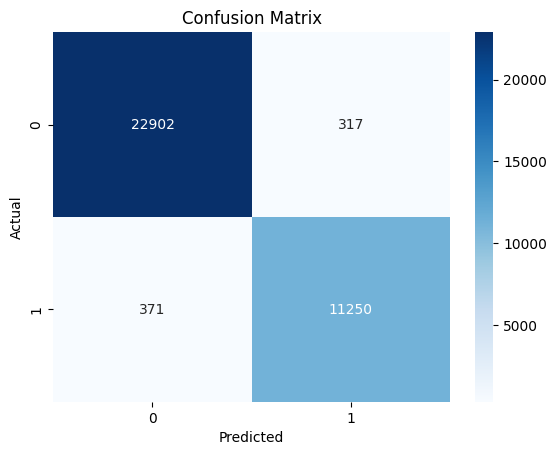

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, voting_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

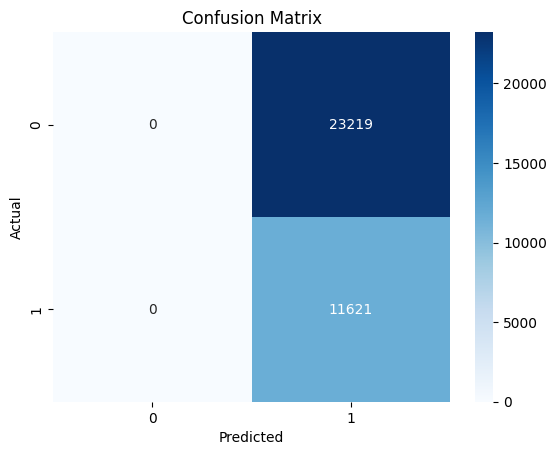

In [38]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, logreg_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

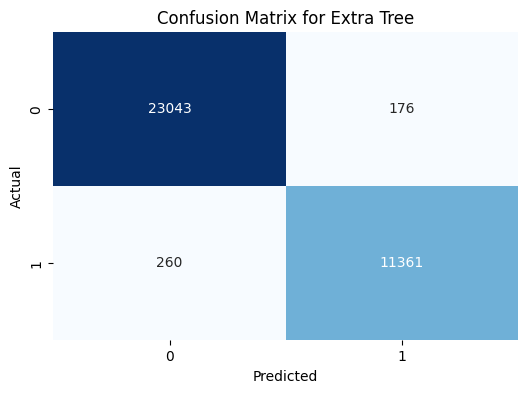

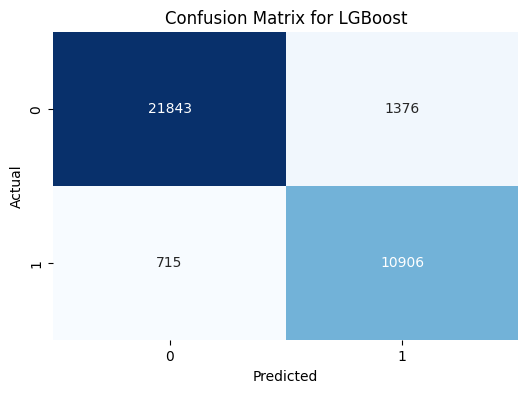

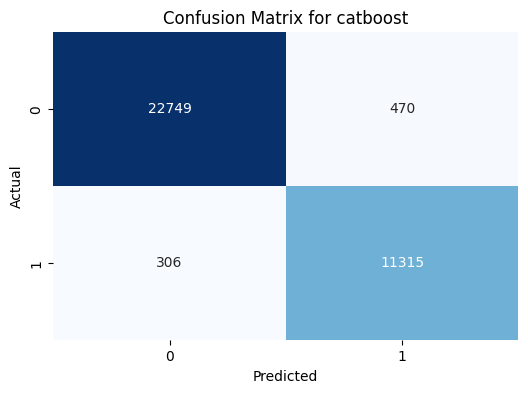

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming rf_pred, svc_pred, and gb_pred are predictions from Random Forest, SVM, and Gradient Boosting models
predictions = { 'Extra Tree' : et_pred,  'LGBoost': lgb_pred, 'catboost' : catboost_pred}

for model_name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)  # Calculate the confusion matrix
    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


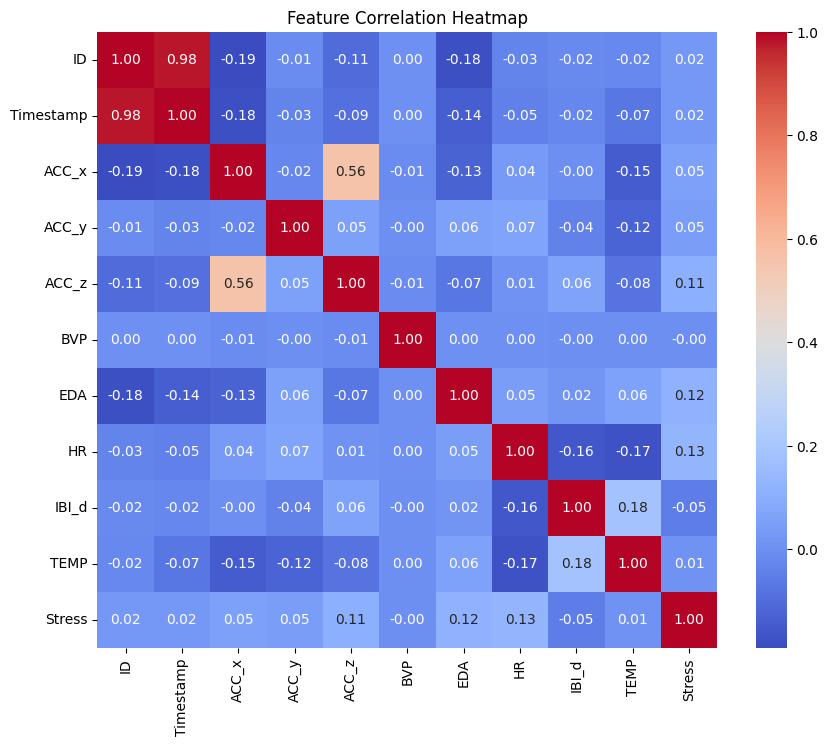

In [40]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

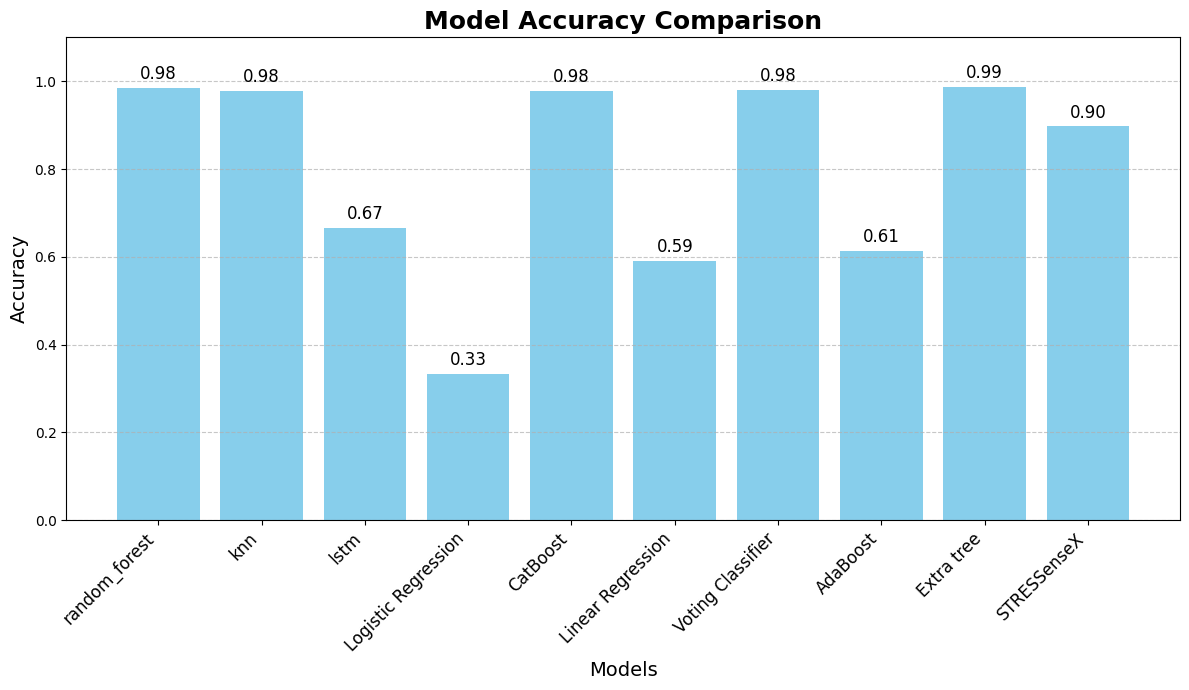

In [46]:
import matplotlib.pyplot as plt

# Assuming you have calculated these accuracies
model_accuracies = {
    'random_forest': rf_accuracy,
    'knn': knn_accuracy,
    'lstm': lstm_accuracy,

    'Logistic Regression': logreg_accuracy,
    'CatBoost': catboost_accuracy,
    'Linear Regression': linear_reg_accuracy,
    'Voting Classifier': voting_accuracy,
    'AdaBoost' : adaboost_accuracy,
    'Extra tree': et_accuracy,
    'STRESSenseX': stress_accuracy
    }

# Plotting the bar chart
plt.figure(figsize=(12, 7))  # Adjusted figure size for better visualization
bars = plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')

# Adding x-axis labels with rotation
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1.1)  # Extend y-axis slightly above 1 for better label placement
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding accuracy values above the bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate (center of the bar)
        bar.get_height() + 0.02,  # Y-coordinate (just above the bar)
        f'{bar.get_height():.2f}',  # Accuracy formatted to 2 decimal places
        ha='center',  # Center-aligned text
        fontsize=12,  # Slightly larger font for readability
        color='black'  # Text color
    )

# Final layout adjustments and display
plt.tight_layout()
plt.show()


**SHAP Explainability**

ExactExplainer explainer: 21it [00:54,  2.70s/it]
/tmp/ipython-input-4087580264.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,1].values, X_test[:20], feature_names=X.columns) # Using[:,:,1] to explain the positive class


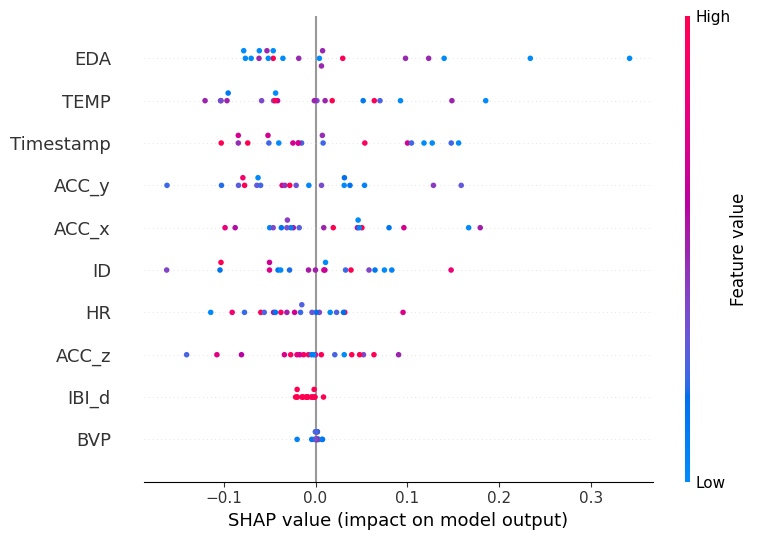

In [50]:
# %%
# Create a wrapper function for the PyTorch model to be compatible with SHAP
def predict_proba_wrapper(numpy_input):
    # Convert numpy array to torch tensor
    torch_input = torch.tensor(numpy_input, dtype=torch.float32).to(device)
    # Get predictions from the model
    with torch.no_grad():
        # Get probabilities for each class
        outputs = model(torch_input)
        # Apply softmax to get probabilities if your model doesn't already
        if model.classifier[-1].__class__.__name__ != 'Softmax':
             probabilities = torch.softmax(outputs, dim=1)
        else:
             probabilities = outputs
    # Return the probabilities as a numpy array
    return probabilities.cpu().numpy()

# Compute SHAP values (use small subset for speed)
# Use a background dataset for the explainer
background = X_train_t[:100].cpu().numpy() # Convert background to NumPy

# Initialize the explainer with the wrapper function and background data
explainer = shap.Explainer(predict_proba_wrapper, background)

# Convert X_test_t to a NumPy array before passing it to the explainer
shap_values = explainer(X_test_t[:20].cpu().numpy())

# Visualize feature importance
# Use the column names from the original X DataFrame for feature_names
shap.summary_plot(shap_values[:,:,1].values, X_test[:20], feature_names=X.columns) # Using[:,:,1] to explain the positive class